### PyGrad demo

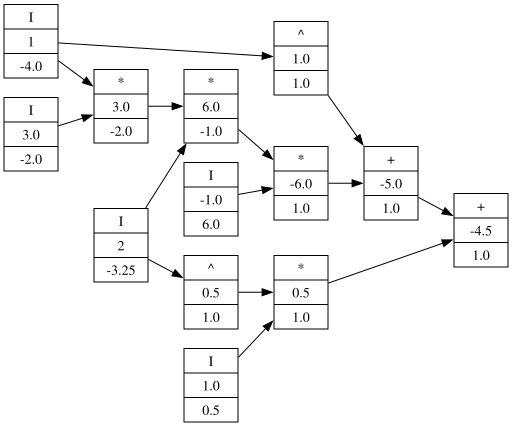

In [1]:
from pygrad.value import Value
from pygrad.utils import draw_graph


def f(x, y):
    return x ** 2 - 3 * x * y + 1 / y


x, y = Value(1), Value(2)
result = f(x, y)
result.backward()
draw_graph(result)

In [2]:
EPS = 1e-6
grad_x = (f(x.data + EPS, y.data) - f(x.data, y.data)) / EPS
grad_y = (f(x.data, y.data + EPS) - f(x.data, y.data)) / EPS
f(x.data, y.data), grad_x, grad_y

(-4.5, -3.9999989986938544, -3.249999875443166)

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1024, noise=0.1)
y = [2 * yi - 1 for yi in y]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

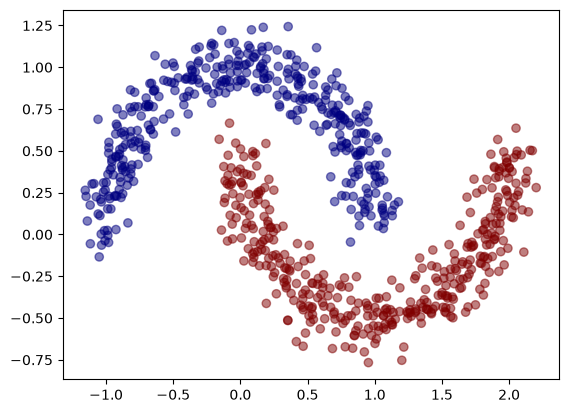

In [4]:
import matplotlib.pyplot as plt 

plt.scatter(X_train[:, 0], X_train[:, 1], alpha=0.5, c=y_train, cmap='jet')

In [5]:
from pygrad.nn import MLP
from pygrad.train import TrainArgs, DataLoader, max_margin_loss, train


args = TrainArgs(n_epochs=100, min_lr=1e-4, max_lr=1e-2)
model = MLP(2, 8, 16, 8, 1)
data_loader = DataLoader(X_train, y_train)
train(args, model, data_loader, max_margin_loss)

Epoch 1 / 100: loss = 0.7863628467628493
Epoch 2 / 100: loss = 0.5718916530076297
Epoch 3 / 100: loss = 0.386962859786975
Epoch 4 / 100: loss = 0.2920432460894033
Epoch 5 / 100: loss = 0.25630164170752673
Epoch 6 / 100: loss = 0.2277583055784911
Epoch 7 / 100: loss = 0.20575324633189795
Epoch 8 / 100: loss = 0.18483659320661505
Epoch 9 / 100: loss = 0.1599172801325811
Epoch 10 / 100: loss = 0.14975952816407523
Epoch 11 / 100: loss = 0.13641355466747088
Epoch 12 / 100: loss = 0.12620872000644387
Epoch 13 / 100: loss = 0.11261532683622956
Epoch 14 / 100: loss = 0.09871689488497781
Epoch 15 / 100: loss = 0.09203613446718711
Epoch 16 / 100: loss = 0.08226278882234052
Epoch 17 / 100: loss = 0.07286356927561896
Epoch 18 / 100: loss = 0.06565296007218381
Epoch 19 / 100: loss = 0.060051180682556805
Epoch 20 / 100: loss = 0.05269314931535973
Epoch 21 / 100: loss = 0.04909019294947728
Epoch 22 / 100: loss = 0.043691818633595086
Epoch 23 / 100: loss = 0.041123000993397905
Epoch 24 / 100: loss = 0

In [6]:
def calc_accuracy(model, X, target):
    make_pred = lambda x: 1 if model(x)[0].data > 0 else -1
    pred = map(make_pred, X)
    return sum(p == y for p, y in zip(pred, target)) / len(X)

calc_accuracy(model, X_test, y_test)

np.float64(0.99609375)